### RaschPy vector-by-items MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the items parameterisation, each rater has a separate severity for every item (rather than a single scalar severity as in the global model).

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if the data is disconnected — i.e. there is no chain of persons and items linking every item to every other, the resulting item locations are not on a common scale, even though `calibrate()` will still run without error. Here we build a small, deliberately disconnected data set as an example: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Items(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_96554/2938009214.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Items(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5,
                        facet_range=1, missing=0, seed=999)
sim.responses.to_csv('mfrm_items_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_items_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     3.0     2.0     3.0     3.0     3.0     3.0   
        Person_2     1.0     2.0     2.0     1.0     2.0     2.0     3.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     4.0     4.0      3.0      3.0      4.0  
        Person_2     3.0     4.0      3.0      1.0      3.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the items parameterisation (a separate severity per rater x item combination). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_items()

CPU times: user 3.41 ms, sys: 311 μs, total: 3.72 ms
Wall time: 3.57 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items

Item_1     0.988432
Item_2     0.304459
Item_3    -0.463869
Item_4     0.653066
Item_5     0.990584
Item_6    -0.155135
Item_7    -0.218960
Item_8    -0.989786
Item_9    -0.813480
Item_10   -0.233285
Item_11   -0.861153
Item_12    0.799126
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


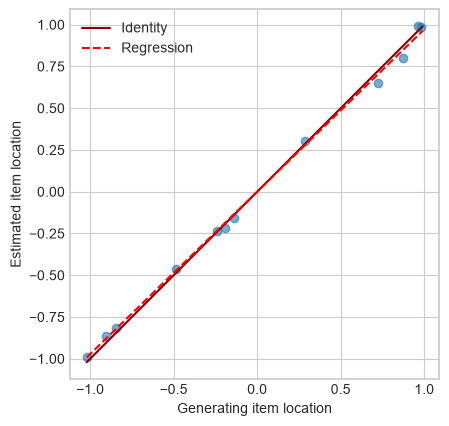

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 0.973
item location regression coefficient:            0.972
item location RMSE:                              0.037


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_items_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_items(full=True)
mfrm.item_stats_items.to_csv('mfrm_items_item_stats.csv')

CPU times: user 3.33 s, sys: 250 ms, total: 3.58 s
Wall time: 3.58 s


Check the item statistics table

In [14]:
mfrm.item_stats_items

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.988,0.050,0.895,1.084,1600,0.431,0.985,-0.409,0.987,-0.347,0.666,0.675
Item_2,0.304,0.041,0.228,0.386,1600,0.495,0.937,-1.820,0.926,-2.142,0.695,0.670
Item_3,-0.464,0.043,-0.547,-0.383,1600,0.572,0.967,-0.923,0.956,-1.258,0.633,0.647
Item_4,0.653,0.047,0.569,0.750,1600,0.463,0.931,-1.977,0.925,-2.152,0.696,0.676
Item_5,0.991,0.040,0.911,1.070,1600,0.434,0.912,-2.564,0.909,-2.633,0.704,0.683
Item_6,-0.155,0.043,-0.236,-0.076,1600,0.543,0.932,-1.952,0.932,-1.949,0.673,0.656
Item_7,-0.219,0.042,-0.303,-0.141,1600,0.546,0.976,-0.681,0.981,-0.525,0.648,0.653
Item_8,-0.990,0.047,-1.082,-0.896,1600,0.609,0.984,-0.442,0.986,-0.383,0.634,0.630
Item_9,-0.813,0.045,-0.903,-0.726,1600,0.598,0.947,-1.514,0.969,-0.866,0.647,0.636
Item_10,-0.233,0.042,-0.315,-0.157,1600,0.548,0.921,-2.295,0.906,-2.732,0.665,0.655


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_items(full=True)
mfrm.threshold_stats_items.to_csv('mfrm_items_threshold_stats.csv')

CPU times: user 93.5 ms, sys: 2.3 ms, total: 95.8 ms
Wall time: 95.5 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_items

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-4.203,0.066,-4.290,-4.025,0.909,-2.438,0.821,-2.537,1.077,0.394,0.374
Threshold 2,-1.419,0.040,-1.496,-1.332,0.990,-0.895,0.993,-0.398,1.023,0.725,0.701
Threshold 3,-1.102,0.035,-1.166,-1.027,0.980,-1.878,0.962,-1.937,1.034,0.934,0.898
Threshold 4,2.393,0.038,2.306,2.451,0.960,-3.008,0.917,-3.209,1.051,0.742,0.713
Threshold 5,4.332,0.068,4.151,4.419,0.887,-2.188,0.879,-1.309,1.066,0.167,0.183


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

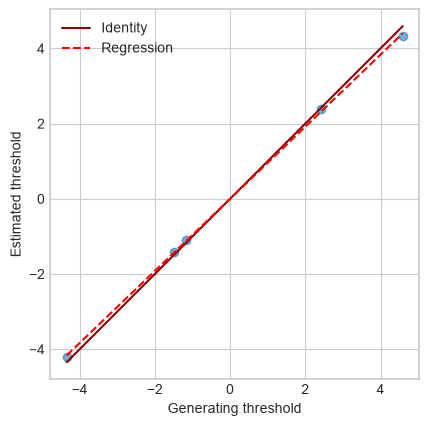

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 0.958
threshold regression coefficient:            0.958
threshold RMSE:                              0.14


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_items_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [18]:
%%time
mfrm.rater_stats_df_items()
mfrm.rater_stats_items.to_csv('mfrm_items_rater_stats.csv')

CPU times: user 43.6 ms, sys: 781 μs, total: 44.4 ms
Wall time: 44.3 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_items

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.268  0.115    0.210  0.116   -0.003  0.117    0.054  0.117   
Rater_2    0.530  0.122   -0.014  0.131   -0.383  0.129   -0.490  0.126   
Rater_3   -0.232  0.120    0.085  0.127   -0.019  0.124   -0.276  0.120   
Rater_4    0.343  0.117    0.014  0.125   -0.228  0.126    0.335  0.121   
Rater_5   -0.417  0.123   -0.024  0.124    0.017  0.129    0.133  0.125   
Rater_6   -0.161  0.116    0.256  0.115   -0.046  0.128   -0.040  0.120   
Rater_7    0.000  0.116   -0.497  0.120    0.378  0.124    0.199  0.125   
Rater_8   -0.332  0.133   -0.030  0.120    0.283  0.134    0.084  0.120   

          Item_5         ... Item_9  Item_10         Item_11         Item_12  \
        Estimate     SE  ...     SE Estimate     SE Estimate     SE Estimate   
Rater_1   -0.250  0.121  ...  0.126   -0.289  0.114    0.020  0.131   -0.166   
Rater_2   -0.007  0.112  ...  0.125   -0.243  0.117   -0.624  0.129    0.273   
Rater_3   -0.175  0.129  ...  0.128    0.360  0.127   -0.106  0.126   -0.036   
Rater_4    0.400  0.117  ...  0.127   -0.140  0.121    0.246  0.133    0.320   
Rater_5   -0.038  0.115  ...  0.133    0.091  0.126   -0.005  0.117    0.169   
Rater_6    0.137  0.120  ...  0.128    0.111  0.119   -0.135  0.127   -0.260   
Rater_7   -0.050  0.125  ...  0.121    0.175  0.125   -0.002  0.130   -0.257   
Rater_8   -0.017  0.118  ...  0.118   -0.066  0.125    0.605  0.125   -0.043   

               Overall statistics                     
            SE              Count Infit MS Outfit MS  
Rater_1  0.111             2400.0    0.943     0.934  
Rater_2  0.118             2400.0    0.961     0.968  
Rater_3  0.122             2400.0    1.008     1.004  
Rater_4  0.122             2400.0    0.936     0.933  
Rater_5  0.111             2400.0    0.965     0.960  
Rater_6  0.116             2400.0    0.971     0.985  
Rater_7  0.117             2400.0    0.882     0.873  
Rater_8  0.116             2400.0    0.950     0.936  

[8 rows x 27 columns]

And the same recovery check for rater x item severities, against `mfrm.generating.facet_effects`. Since these are per rater x item, we flatten with `.unstack()` first:

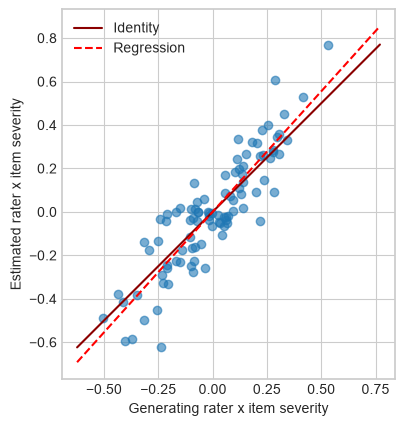

rater x item severity Pearson correlation:              0.884
rater x item severity SD ratio (estimated / generating): 1.255
rater x item severity regression coefficient:            1.109
rater x item severity RMSE:                              0.124


In [20]:
orig_severities = mfrm.generating.facet_effects.unstack()
est_severities = mfrm.raters_items.unstack()
recovery_plot(orig_severities, est_severities, 'rater x item severity', 'my_mfrm_items_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_items(full=True)
mfrm.person_stats_items.to_csv('mfrm_items_person_stats.csv')

CPU times: user 14 ms, sys: 673 μs, total: 14.7 ms
Wall time: 14.6 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_items.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,1.205,0.170,0.167,303,480,0.631,0.960,0.969,-0.169,-0.118
Person_2,-0.433,0.140,0.148,236,480,0.492,1.126,1.166,0.911,1.067
Person_3,-2.827,0.149,0.153,105,480,0.219,1.053,1.013,0.393,0.133
Person_4,0.115,0.152,0.156,262,480,0.546,1.063,0.974,0.439,-0.095
Person_5,0.776,0.166,0.170,288,480,0.600,1.050,1.071,0.337,0.443
Person_6,-0.567,0.137,0.133,229,480,0.477,0.933,0.956,-0.457,-0.248
Person_7,-0.805,0.134,0.134,216,480,0.450,0.998,1.036,0.026,0.297
Person_8,-1.155,0.131,0.144,196,480,0.408,1.208,1.183,1.564,1.332
Person_9,0.721,0.165,0.167,286,480,0.596,1.027,1.037,0.208,0.263
Person_10,-1.581,0.131,0.135,171,480,0.356,1.071,1.063,0.587,0.505


And the same recovery check for person locations, against `mfrm.generating.persons`:

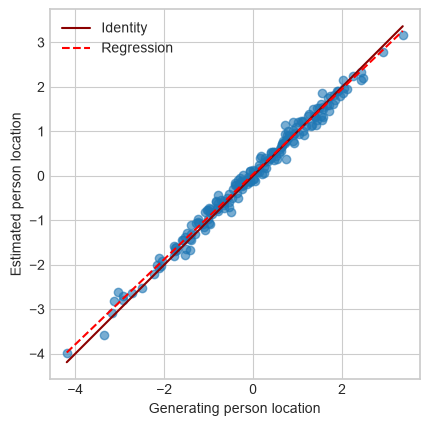

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 0.963
person location regression coefficient:            0.957
person location RMSE:                              0.156


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_items, 'person location', 'my_mfrm_items_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_items()
mfrm.test_stats_items.to_csv('mfrm_items_test_stats.csv')

CPU times: user 2.68 ms, sys: 560 μs, total: 3.24 ms
Wall time: 3.14 ms


Check the test statistics table

In [25]:
mfrm.test_stats_items

,Items,Persons
Mean,-0.000,0.039
SD,0.729,1.282
Separation ratio,16.455,8.558
Strata,22.274,11.744
Reliability,0.996,0.987


Run a residual correlation analysis for items (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_items()
mfrm.item_residual_correlations_items.to_csv('mfrm_items_item_residual_correlations.csv')
mfrm.item_loadings_items.to_csv('mfrm_items_item_loadings.csv')

CPU times: user 8.68 ms, sys: 2.85 ms, total: 11.5 ms
Wall time: 16 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [27]:
round(mfrm.item_residual_correlations_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,0.006,-0.042,-0.027,-0.033,-0.072,-0.025,-0.015,-0.026,-0.058,0.025,-0.019
Item_2,0.006,1.000,-0.048,-0.036,-0.028,-0.014,-0.010,-0.046,-0.005,0.030,0.007,0.052
Item_3,-0.042,-0.048,1.000,-0.009,-0.022,0.014,0.009,-0.004,-0.019,0.015,0.016,-0.031
Item_4,-0.027,-0.036,-0.009,1.000,0.009,-0.030,0.040,-0.006,-0.054,-0.064,0.002,-0.028
Item_5,-0.033,-0.028,-0.022,0.009,1.000,0.009,-0.034,-0.023,-0.028,0.015,-0.009,0.006
Item_6,-0.072,-0.014,0.014,-0.030,0.009,1.000,0.030,-0.033,0.032,-0.032,0.024,-0.032
Item_7,-0.025,-0.010,0.009,0.040,-0.034,0.030,1.000,-0.010,-0.024,-0.010,-0.036,0.009
Item_8,-0.015,-0.046,-0.004,-0.006,-0.023,-0.033,-0.010,1.000,-0.034,-0.030,0.001,-0.000
Item_9,-0.026,-0.005,-0.019,-0.054,-0.028,0.032,-0.024,-0.034,1.000,-0.046,-0.036,-0.035
Item_10,-0.058,0.030,0.015,-0.064,0.015,-0.032,-0.010,-0.030,-0.046,1.000,0.050,-0.037


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_items['PC 1'], 3)

Item_1     0.148
Item_2     0.161
Item_3    -0.122
Item_4    -0.076
Item_5    -0.017
Item_6    -0.147
Item_7    -0.089
Item_8    -0.010
Item_9    -0.049
Item_10    0.039
Item_11    0.037
Item_12    0.115
Name: PC 1, dtype: float64

Run a residual correlation analysis for raters (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_items()
mfrm.rater_residual_correlations_items.to_csv('mfrm_items_rater_residual_correlations.csv')
mfrm.rater_loadings_items.to_csv('mfrm_items_rater_loadings.csv')

CPU times: user 12.6 ms, sys: 715 μs, total: 13.3 ms
Wall time: 13.3 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [30]:
round(mfrm.rater_residual_correlations_items, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.003,0.020,-0.004,-0.019,0.019,0.024,-0.027
Rater_2,0.003,1.000,-0.028,-0.000,-0.014,0.006,-0.016,0.008
Rater_3,0.020,-0.028,1.000,0.013,-0.012,-0.002,0.003,-0.028
Rater_4,-0.004,-0.000,0.013,1.000,-0.007,-0.025,-0.018,-0.036
Rater_5,-0.019,-0.014,-0.012,-0.007,1.000,-0.040,-0.015,-0.037
Rater_6,0.019,0.006,-0.002,-0.025,-0.040,1.000,-0.023,-0.008
Rater_7,0.024,-0.016,0.003,-0.018,-0.015,-0.023,1.000,-0.051
Rater_8,-0.027,0.008,-0.028,-0.036,-0.037,-0.008,-0.051,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_items['PC 1'], 3)

Rater_1   -0.167
Rater_2    0.174
Rater_3   -0.148
Rater_4    0.010
Rater_5   -0.010
Rater_6    0.015
Rater_7   -0.155
Rater_8    0.249
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

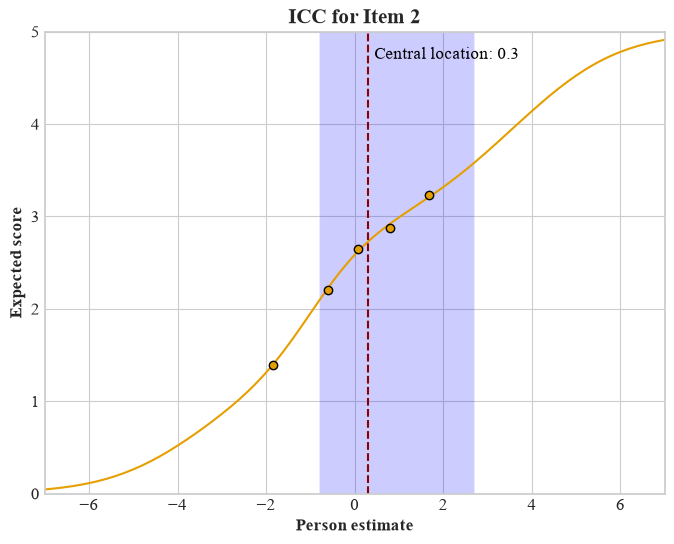

In [32]:
mfrm.icc_items('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_items_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

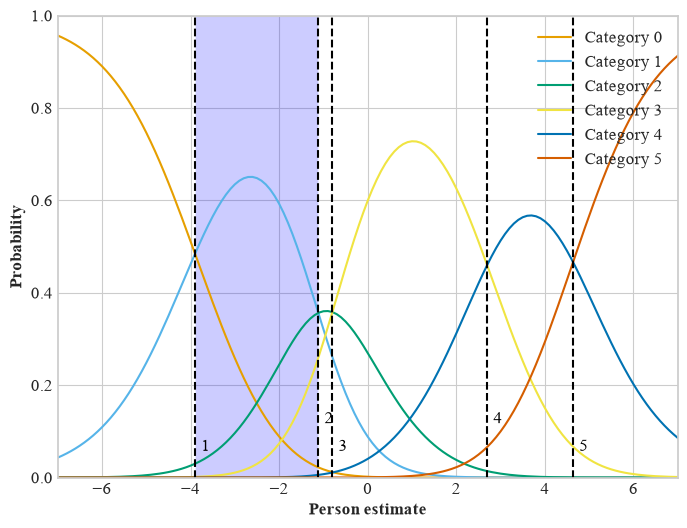

In [33]:
mfrm.crcs_items('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_items_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 3, category 1 highlighted and the thresholds marked

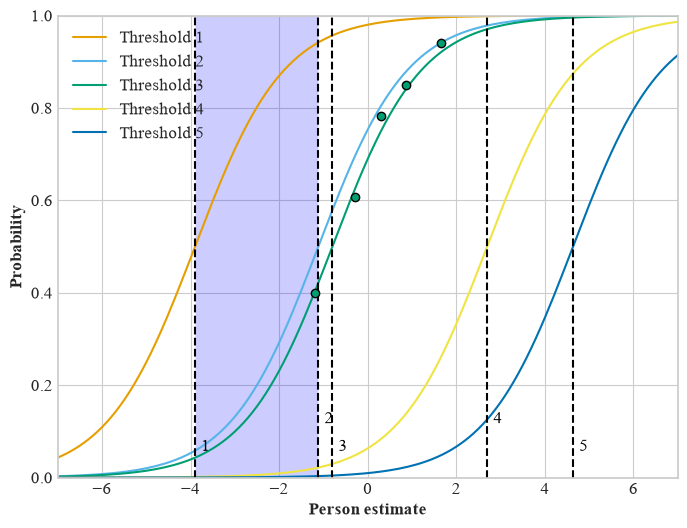

In [34]:
mfrm.threshold_ccs_items('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_items_threshold_ccs')

Produce an item information function curve for Item 2

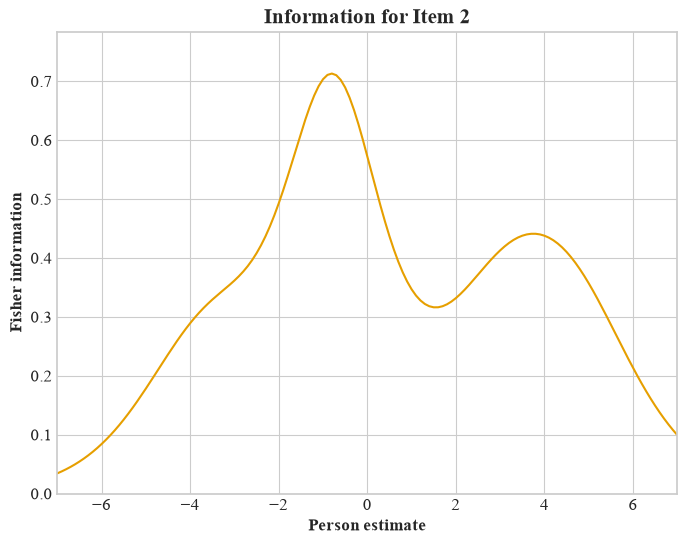

In [35]:
mfrm.iic_items('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_items_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

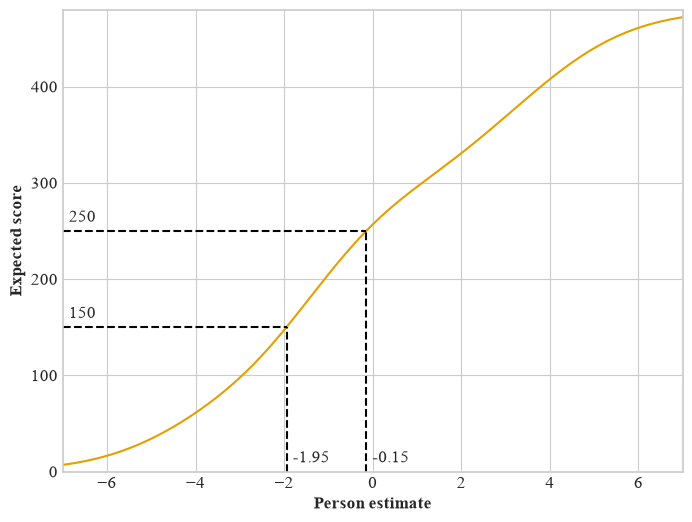

In [36]:
mfrm.tcc_items(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_items_tcc')

Produce a test information curve

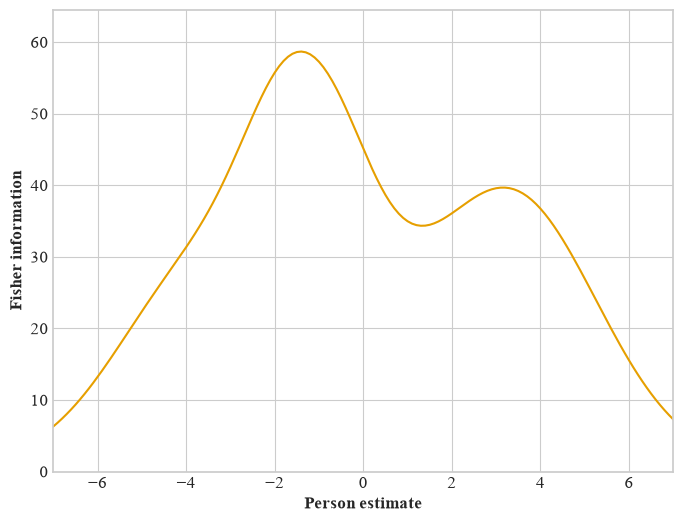

In [37]:
mfrm.test_info_items(xmin=-7, xmax=7, filename='my_mfrm_items_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

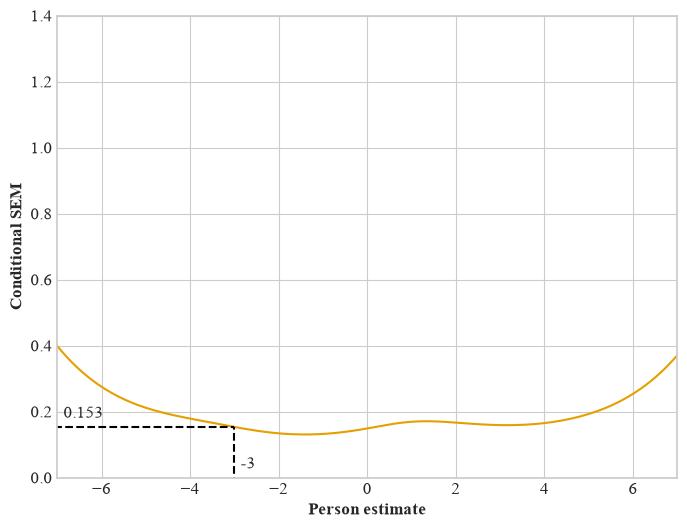

In [38]:
mfrm.test_csem_items(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_items_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

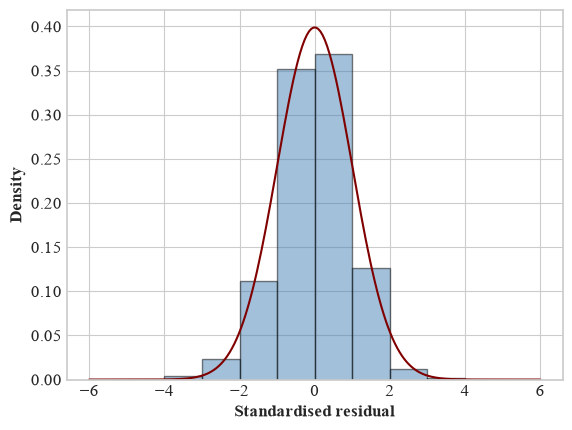

In [39]:
mfrm.std_residuals_plot_items(bin_width=0.6, normal=True, filename='my_mfrm_items_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_items_anchor(anchors)

CPU times: user 1.28 ms, sys: 214 μs, total: 1.49 ms
Wall time: 1.32 ms


Check the anchored item locations against the unanchored ones.

In [41]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_items})
round(item_check, 3)

,Unanchored,Anchored
Item_1,0.988,1.186
Item_2,0.304,0.349
Item_3,-0.464,-0.651
Item_4,0.653,0.530
Item_5,0.991,0.953
Item_6,-0.155,-0.022
Item_7,-0.219,-0.175
Item_8,-0.990,-0.868
Item_9,-0.813,-0.824
Item_10,-0.233,-0.341


Check the anchored rater x item severities against the unanchored ones (two separate dataframes)

In [42]:
round(mfrm.raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.268,0.210,-0.003,0.054,-0.250,0.060,-0.043,0.002,-0.225,-0.289,0.020,-0.166
Rater_2,0.530,-0.014,-0.383,-0.490,-0.007,0.262,0.091,-0.115,0.319,-0.243,-0.624,0.273
Rater_3,-0.232,0.085,-0.019,-0.276,-0.175,0.148,-0.026,-0.052,0.014,0.360,-0.106,-0.036
Rater_4,0.343,0.014,-0.228,0.335,0.400,0.182,0.268,0.770,-0.035,-0.140,0.246,0.320
Rater_5,-0.417,-0.024,0.017,0.133,-0.038,-0.596,-0.379,-0.453,-0.066,0.091,-0.005,0.169
Rater_6,-0.161,0.256,-0.046,-0.040,0.137,-0.176,-0.326,0.005,-0.585,0.111,-0.135,-0.260
Rater_7,0.000,-0.497,0.378,0.199,-0.050,0.074,-0.038,-0.148,0.249,0.175,-0.002,-0.257
Rater_8,-0.332,-0.030,0.283,0.084,-0.017,0.047,0.452,-0.009,0.329,-0.066,0.605,-0.043


In [43]:
round(mfrm.anchor_raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.040,0.136,0.155,0.148,-0.242,-0.103,-0.116,-0.150,-0.243,-0.211,0.136,-0.264
Rater_2,0.303,-0.088,-0.224,-0.396,0.001,0.099,0.019,-0.266,0.301,-0.165,-0.508,0.176
Rater_3,-0.459,0.011,0.139,-0.181,-0.167,-0.015,-0.099,-0.203,-0.004,0.438,0.010,-0.134
Rater_4,0.116,-0.060,-0.070,0.430,0.408,0.019,0.195,0.619,-0.053,-0.062,0.362,0.222
Rater_5,-0.644,-0.098,0.175,0.227,-0.030,-0.759,-0.452,-0.604,-0.084,0.170,0.111,0.071
Rater_6,-0.388,0.182,0.112,0.054,0.145,-0.339,-0.399,-0.146,-0.604,0.190,-0.019,-0.358
Rater_7,-0.227,-0.571,0.536,0.294,-0.041,-0.089,-0.111,-0.299,0.231,0.253,0.114,-0.355
Rater_8,-0.559,-0.104,0.441,0.178,-0.009,-0.115,0.379,-0.161,0.311,0.012,0.722,-0.141


Produce a Wright map (unanchored), showing the person location distribution alongside an item strip (one row per item, divided into its own category segments at each Rasch-Andrich threshold) and a rater panel, with mean/±1SD/±2SD reference marks for persons

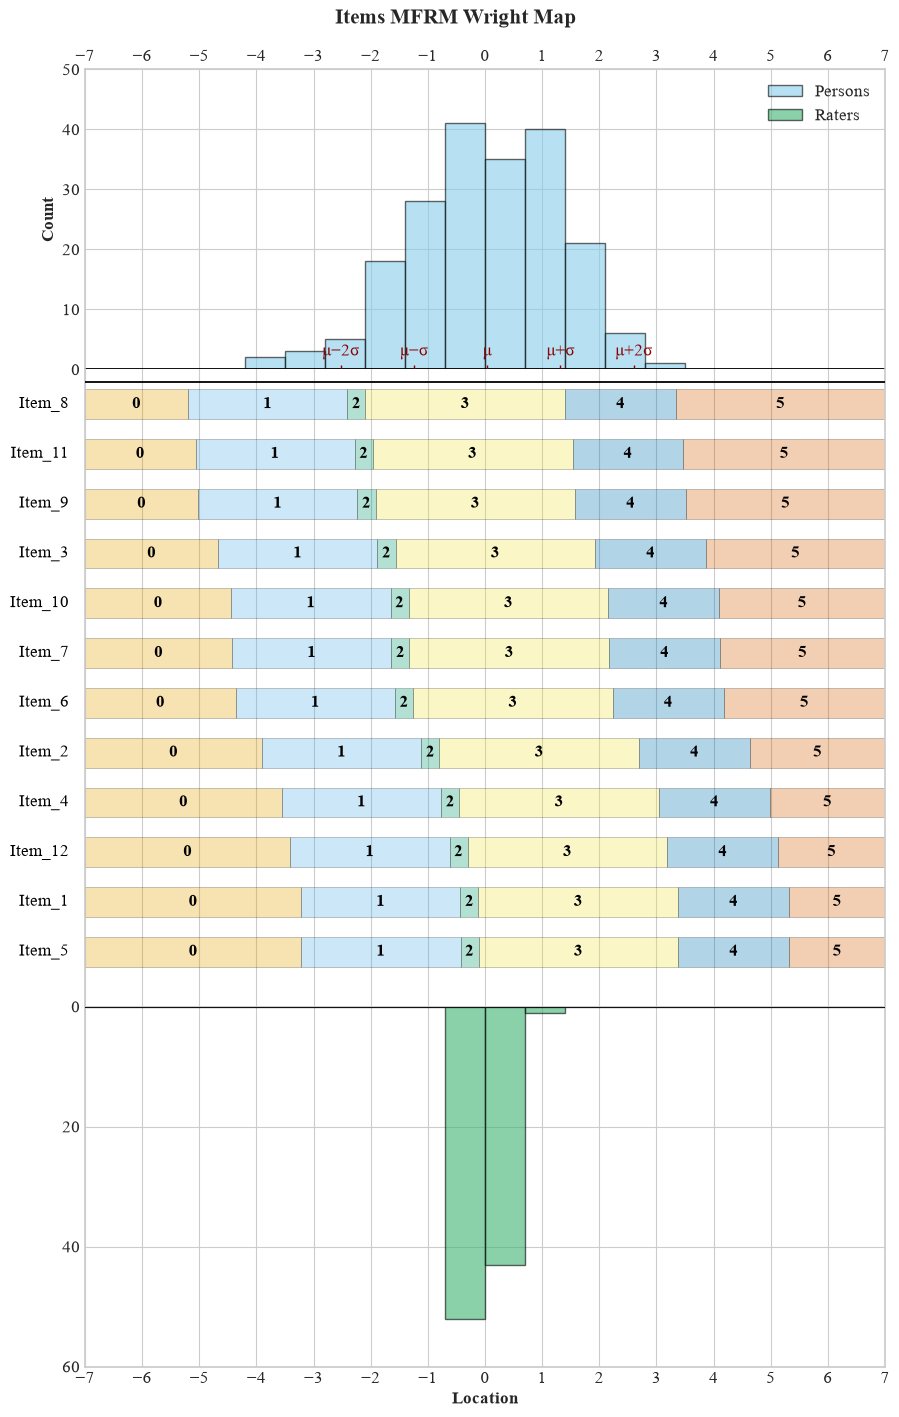

In [44]:
mfrm.wright_map_items(item_strip=True, facet_labels=False, distribution_markers=True, title='Items MFRM Wright Map', filename='my_mfrm_items_wright_map')